In [1]:
import pandas as pd

df = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["label", "message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (5572, 2)
Columns: ['label', 'message']


In [3]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
label      0
message    0
dtype: int64


In [4]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
X = df["message"]
y = df["label"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (5572,)
Target: (5572,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

Training matrix shape: (4457, 7668)
Testing matrix shape: (1115, 7668)


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


In [10]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed.")

Predictions completed.


In [11]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)

precision = precision_score(y_test, y_pred, pos_label="spam")
recall = recall_score(y_test, y_pred, pos_label="spam")
f1 = f1_score(y_test, y_pred, pos_label="spam")

print("Confusion Matrix:")
print(cm)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Confusion Matrix:
[[966   0]
 [ 30 119]]
Precision: 1.0
Recall: 0.7986577181208053
F1-score: 0.8880597014925373


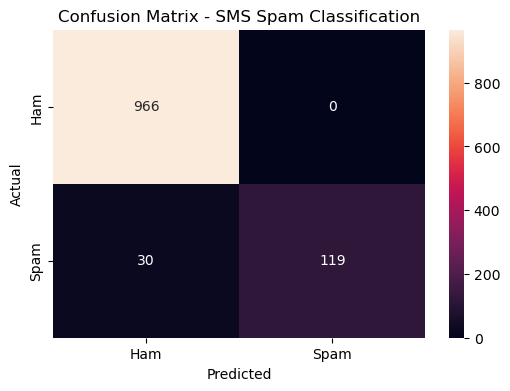

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SMS Spam Classification")
plt.show()

## Results and Analysis

The SMS Spam Classification model was trained using Logistic Regression with TF-IDF features.

### Evaluation Results

- Precision: 1.00
- Recall: 0.7987
- F1-score: 0.8881

### Confusion Matrix

The confusion matrix contains:
- True Negatives (Ham correctly classified): 966
- False Positives: 0
- False Negatives (Spam classified as Ham): 30
- True Positives (Spam correctly classified): 119

### Key Takeaway

The model achieved a precision of 1.00, meaning the messages predicted as spam were correctly classified in the test set. The recall was 0.7987, meaning the model identified most of the spam messages but missed some spam messages. The F1-score of 0.8881 shows a good balance between precision and recall.

Since the dataset contains more ham messages than spam messages, precision, recall and F1-score are more informative than accuracy alone.

In [13]:
print("Dataset shape:", df.shape)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Dataset shape: (5572, 2)
Training samples: 4457
Testing samples: 1115
Precision: 1.0
Recall: 0.7986577181208053
F1-score: 0.8880597014925373
